In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter

from tabulate import tabulate

In [ ]:
# 1. Load RAW data
# We keep these separate so we can always compare 'Before' vs 'After'
loans_raw = pd.read_csv("loans.csv", dtype=str)
perf_raw = pd.read_csv("performance.csv", dtype=str)

# 2. Create copy of original data
loans = loans_raw.copy()
performance = perf_raw.copy()

# 3. Dedup both dataframes
loans = loans.drop_duplicates()
performance = performance.drop_duplicates()

print(f"\nRemoved {len(loans_raw) - len(loans)} duplicates from Loans.")
print(f"\nRemoved {len(perf_raw) - len(performance)} duplicates from Performance.")

print("\n--- Missing Values in Loans ---")
print(loans.isnull().sum())

print("\n--- Missing Values in Performance ---")
print(performance.isnull().sum())




Removed 5 duplicates from Loans.

Removed 0 duplicates from Performance.

--- Missing Values in Loans ---
loan_id              0
origination_date     0
channel              0
loan_amount          0
apr                 25
term_months          0
score_band           0
dtype: int64

--- Missing Values in Performance ---
loan_id    0
month      0
late       0
dtype: int64


In [2]:
# 4. Standardise primary keys to ensure safe joins later
# We strip whitespace and ensure they are strings
loans['loan_id'] = loans['loan_id'].astype(str).str.strip()
performance['loan_id'] = performance['loan_id'].astype(str).str.strip()


In [ ]:
# Coerce variables to numeric
loans['loan_amount'] = pd.to_numeric(loans['loan_amount'], errors='coerce')
loans['apr'] = pd.to_numeric(loans['apr'], errors='coerce')
loans['term_months'] = pd.to_numeric(loans['term_months'], errors='coerce')

performance['late'] = pd.to_numeric(performance['late'], errors='coerce')


In [ ]:
# 5. Targeted Data Cleaning: APR
initial_count = len(loans)

# Drop NaNs
loans = loans.dropna(subset=['apr'])

rows_dropped = initial_count - len(loans)
print(f"Dropped {rows_dropped} rows due to missing APR.")
print(f"Loans remaining: {len(loans):,}")
print("-" * 30)

Dropped 25 rows due to missing APR.
Loans remaining: 9,970
------------------------------


In [6]:
loans['apr'].max()

np.float64(0.2475)

In [ ]:
# Standardize APR format: convert whole numbers (e.g., 15.0) to decimals (0.15) 
# while leaving existing decimals (0.12) unchanged.
loans['apr'] = np.where(loans['apr'] > 1.0, loans['apr'] / 100, loans['apr'])

In [ ]:
# --- Clean Origination Date ---
# Use dayfirst=True to remain consistent with your performance data format
loans['origination_date'] = pd.to_datetime(loans['origination_date'], dayfirst=True)

# --- Calculate and Print Bounds ---
orig_min = loans['origination_date'].min()
orig_max = loans['origination_date'].max()

print(f"Origination Date Range: {orig_min.strftime('%Y-%m-%d')} to {orig_max.strftime('%Y-%m-%d')}")

Origination Date Range: 2025-01-01 to 2025-12-31


In [ ]:
# Create the aggregated version of the performance data
perf_agg = performance.groupby('loan_id').agg(
    # 1. Count how many months of history we have for this loan
    months_on_book=('month', 'count'),
    
    # 2. Check if the loan was EVER late (1 = Yes, 0 = No)
    # Since 'late' is 0 or 1, if the Max is 1, they were late at least once.
    ever_late=('late', 'max') 
).reset_index()

In [ ]:
# Perform an 'outer' join with an indicator to see the full picture
# This doesn't drop anything yet; it just flags them.
audit_df = pd.merge(
    loans[['loan_id']], 
    perf_agg[['loan_id']], 
    on='loan_id', 
    how='outer', 
    indicator=True
)

# Calculate the leakage
loans_only = audit_df[audit_df['_merge'] == 'left_only'].shape[0]
perf_only = audit_df[audit_df['_merge'] == 'right_only'].shape[0]
both = audit_df[audit_df['_merge'] == 'both'].shape[0]

print("--- MERGE INTEGRITY REPORT ---")
print(f"Matched Loans (In both files):      {both:,}")
print(f"Loans missing Performance history:   {loans_only:,}")
print(f"Performance IDs with no Loan Info:  {perf_only:,}")



--- MERGE INTEGRITY REPORT ---
Matched Loans (In both files):      9,970
Loans missing Performance history:   0
Performance IDs with no Loan Info:  30


In [ ]:
# --- Identify Earliest Performance Month ---
# Convert month to datetime to ensure correct sorting/minimums
performance['month'] = pd.to_datetime(performance['month'], dayfirst=True)

# Get the first month record for each loan_id
earliest_perf = performance.groupby('loan_id')['month'].min().reset_index()
earliest_perf.columns = ['loan_id', 'perf_date']

# --- Temporal Bounds Check ---
# Identifying the first and last recorded entry points for the loans
min_date = earliest_perf['perf_date'].min()
max_date = earliest_perf['perf_date'].max()

# Formatting to YYYY-MM-DD for a clean professional output
print(f"Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")


Date Range: 2025-01-31 to 2025-12-31


In [ ]:

# We use an inner join to ensure we drop any records with missing data from one dataset
loans_start = pd.merge(loans, earliest_perf, on='loan_id', how='inner')

# --- Sense Check ---
# Check if any loans failed to find a 'perf_date'
missing_dates = loans_start['perf_date'].isna().sum()
print(f"Loans missing a performance start date: {missing_dates}")

# Preview the alignment
print(loans_start[['loan_id', 'origination_date', 'perf_date']].head())

Loans missing a performance start date: 0
  loan_id origination_date  perf_date
0    2819       2025-07-17 2025-07-31
1    4383       2025-09-11 2025-09-30
2    7714       2025-03-09 2025-03-31
3    8167       2025-06-03 2025-06-30
4    4599       2025-01-27 2025-01-31


In [12]:
loans_start.head()

,loan_id,origination_date,channel,loan_amount,apr,term_months,score_band,perf_date
0,2819,2025-07-17,Branch,8000,0.1095,12,B,2025-07-31
1,4383,2025-09-11,Broker B,4000,0.1834,48,C,2025-09-30
2,7714,2025-03-09,Online,10000,0.1126,12,B,2025-03-31
3,8167,2025-06-03,Online,3000,0.1404,24,C,2025-06-30
4,4599,2025-01-27,Online,5000,0.1261,12,B,2025-01-31


In [13]:
# --- 1. Ensure Datetime Consistency ---
# Re-confirming formats to prevent day/month swapping errors
loans_start['origination_date'] = pd.to_datetime(loans_start['origination_date'], dayfirst=True)
loans_start['perf_date'] = pd.to_datetime(loans_start['perf_date'], dayfirst=True)

# --- 2. Identify Chronological Anomalies ---
# We look for any record where the performance start is EARLIER than origination
invalid_chronology = loans_start[loans_start['perf_date'] < loans_start['origination_date']]
invalid_chronology.shape


(0, 8)

In [14]:
# --- 1. Create the Performance String ---
# We sort by month first to ensure the string is in chronological order
performance_sorted = performance.sort_values(['loan_id', 'month'])

# Concatenate all 'late' entries for each loan_id
perf_strings = performance_sorted.groupby('loan_id')['late'].apply(
    lambda x: "".join(x.astype(str))
).reset_index()

# Rename the column to 'performance_history' to distinguish it
perf_strings.columns = ['loan_id', 'performance_history']

# --- 2. Merge into loans_start ---
loans_start = pd.merge(loans_start, perf_strings, on='loan_id', how='left')

# Fill missing histories (for loans with no performance data) with an empty string
loans_start['performance_history'] = loans_start['performance_history'].fillna("")

# --- 3. Verify the Output ---
print(loans_start[['loan_id', 'performance_history']].head())

  loan_id performance_history
0    2819              000000
1    4383                0000
2    7714          0000000000
3    8167             0000000
4    4599        000000000000


In [ ]:
# Create a helper for the total count of '1's in the string
loans_start['total_late_events'] = loans_start['performance_history'].str.count('1')

# Apply the frequency logic - no identifier for number of payments in arrears, just missed payment flag
loans_start['delFlag_1'] = (loans_start['total_late_events'] == 1).astype(int)
loans_start['delFlag_2'] = (loans_start['total_late_events'] == 2).astype(int)
loans_start['delFlag_3plus'] = (loans_start['total_late_events'] >= 3).astype(int)

# Check a sample of a '2' count to ensure accuracy
print(loans_start[loans_start['delFlag_2'] == 1][['performance_history', 'delFlag_2']].head())

    performance_history  delFlag_2
205             1010000          1
325         10001000000          1
381        010000000100          1
626             1100000          1
873          0000010100          1


In [16]:
print(loans_start.head())

  loan_id origination_date   channel  loan_amount     apr  term_months  \
0    2819       2025-07-17    Branch         8000  0.1095           12   
1    4383       2025-09-11  Broker B         4000  0.1834           48   
2    7714       2025-03-09    Online        10000  0.1126           12   
3    8167       2025-06-03    Online         3000  0.1404           24   
4    4599       2025-01-27    Online         5000  0.1261           12   

  score_band  perf_date performance_history  total_late_events  delFlag_1  \
0          B 2025-07-31              000000                  0          0   
1          C 2025-09-30                0000                  0          0   
2          B 2025-03-31          0000000000                  0          0   
3          C 2025-06-30             0000000                  0          0   
4          B 2025-01-31        000000000000                  0          0   

   delFlag_2  delFlag_3plus  
0          0              0  
1          0              0  
2 

In [17]:
loans_start['total_late_events'].value_counts()

total_late_events
0    8794
1    1110
2      60
3       5
4       1
Name: count, dtype: int64

In [18]:
# --- 1. Define the Observation End Date ---
end_date = pd.to_datetime('2025-12-31')

# --- 2. Calculate Months on Book (MOB) ---
# We calculate the total month difference between the two dates
loans_start['months_on_book'] = (
    (end_date.year - loans_start['origination_date'].dt.year) * 12 + 
    (end_date.month - loans_start['origination_date'].dt.month) + 1
)

# --- 3. Validation ---
# Ensure no negative months (in case of data entry errors post-Dec 2025)
loans_start['months_on_book'] = loans_start['months_on_book'].clip(lower=1)

# Preview the tenure distribution
loans_start.head()

,loan_id,origination_date,channel,loan_amount,apr,term_months,score_band,perf_date,performance_history,total_late_events,delFlag_1,delFlag_2,delFlag_3plus,months_on_book
0,2819,2025-07-17,Branch,8000,0.1095,12,B,2025-07-31,000000,0,0,0,0,6
1,4383,2025-09-11,Broker B,4000,0.1834,48,C,2025-09-30,0000,0,0,0,0,4
2,7714,2025-03-09,Online,10000,0.1126,12,B,2025-03-31,0000000000,0,0,0,0,10
3,8167,2025-06-03,Online,3000,0.1404,24,C,2025-06-30,0000000,0,0,0,0,7
4,4599,2025-01-27,Online,5000,0.1261,12,B,2025-01-31,000000000000,0,0,0,0,12


In [20]:
loans_start['months_on_book'].value_counts().sort_index()

months_on_book
1      596
2      601
3      808
4      887
5      985
6     1154
7     1109
8      976
9      858
10     688
11     711
12     597
Name: count, dtype: int64

In [ ]:
# Create a copy of final dataframe used for creating analytics
df_final = loans_start.copy()

In [22]:
list(df_final)

['loan_id',
 'origination_date',
 'channel',
 'loan_amount',
 'apr',
 'term_months',
 'score_band',
 'perf_date',
 'performance_history',
 'total_late_events',
 'delFlag_1',
 'delFlag_2',
 'delFlag_3plus',
 'months_on_book']

In [23]:
print(df_final.head())

  loan_id origination_date   channel  loan_amount     apr  term_months  \
0    2819       2025-07-17    Branch         8000  0.1095           12   
1    4383       2025-09-11  Broker B         4000  0.1834           48   
2    7714       2025-03-09    Online        10000  0.1126           12   
3    8167       2025-06-03    Online         3000  0.1404           24   
4    4599       2025-01-27    Online         5000  0.1261           12   

  score_band  perf_date performance_history  total_late_events  delFlag_1  \
0          B 2025-07-31              000000                  0          0   
1          C 2025-09-30                0000                  0          0   
2          B 2025-03-31          0000000000                  0          0   
3          C 2025-06-30             0000000                  0          0   
4          B 2025-01-31        000000000000                  0          0   

   delFlag_2  delFlag_3plus  months_on_book  
0          0              0               6  


In [ ]:
print("\n[CHANNELS]:\n", df_final['channel'].value_counts())
print("\n[SCORE BANDS]:\n", df_final['score_band'].value_counts())
print("\n[DEFAULT RATE]:\n", df_final['total_late_events'].mean())


[CHANNELS]:
 channel
Direct      3299
Online      2634
Broker A    1803
Broker B    1307
Branch       927
Name: count, dtype: int64

[SCORE BANDS]:
 score_band
B    3093
C    2695
A    2495
D    1687
Name: count, dtype: int64

[DEFAULT RATE]:
 0.12527582748244734


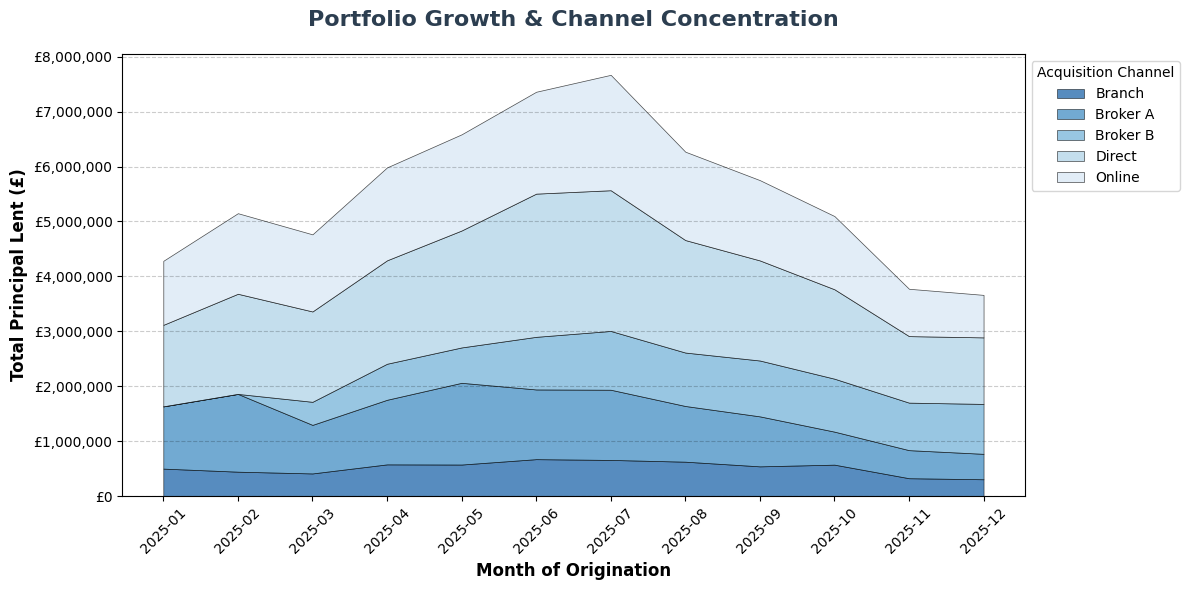

In [ ]:


# 1. Data Prep
df_final['origination_month_str'] = df_final['origination_date'].dt.strftime('%Y-%m')
balance_trend = df_final.groupby(['origination_month_str', 'channel'])['loan_amount'].sum().unstack(fill_value=0)

# 2. Plotting (Using stackplot for precise edge control)
fig, ax = plt.subplots(figsize=(12, 6))
pal = sns.color_palette("Blues_r", len(balance_trend.columns))

# We use ax.stackplot to allow for the 'edgecolor' on the polygons
ax.stackplot(balance_trend.index, balance_trend.T, labels=balance_trend.columns, 
             colors=pal, alpha=0.7, edgecolor='black', linewidth=0.5)

# 3. Professional Formatting
plt.title('Portfolio Growth & Channel Concentration', fontsize=16, pad=20, fontweight='bold', color='#2C3E50')
plt.ylabel('Total Principal Lent (£)', fontsize=12, fontweight='bold')
plt.xlabel('Month of Origination', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.legend(title='Acquisition Channel', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.grid(axis='y', alpha=0.2, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

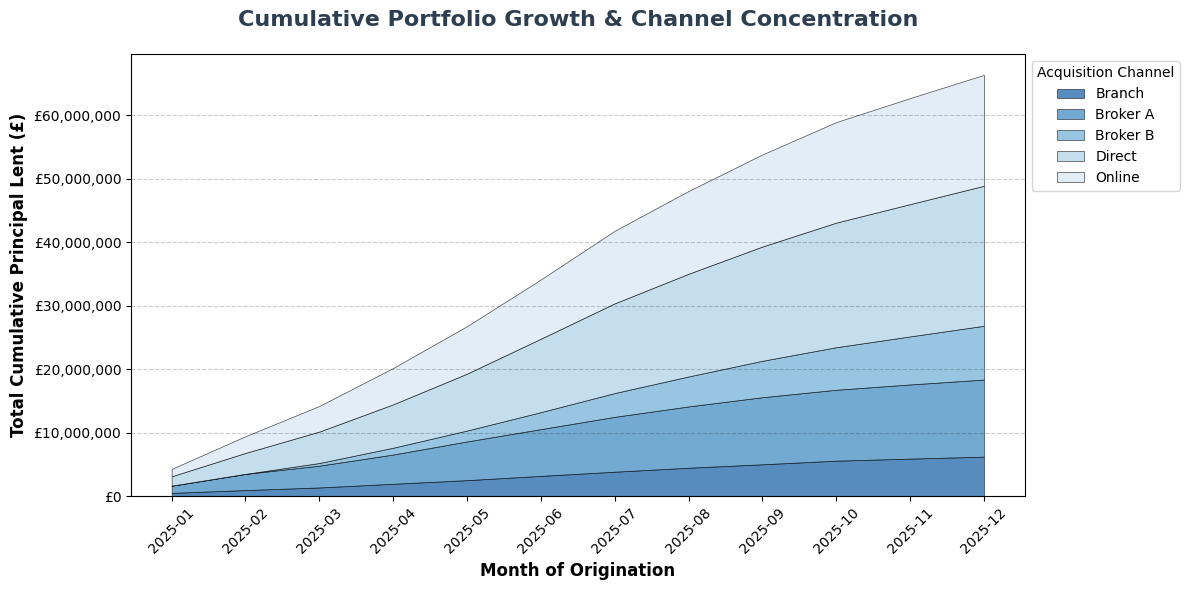

{'action': 'Generate Cumulative Chart', 'missing_apr_dropped': True, 'aggregation': 'Cumulative Sum (Time Series)'}


In [ ]:


# Group by month and channel, unstack, and then apply .cumsum() to make it cumulative
balance_trend = (df_final.groupby(['origination_month_str', 'channel'])['loan_amount']
                 .sum()
                 .unstack(fill_value=0)
                 .cumsum())

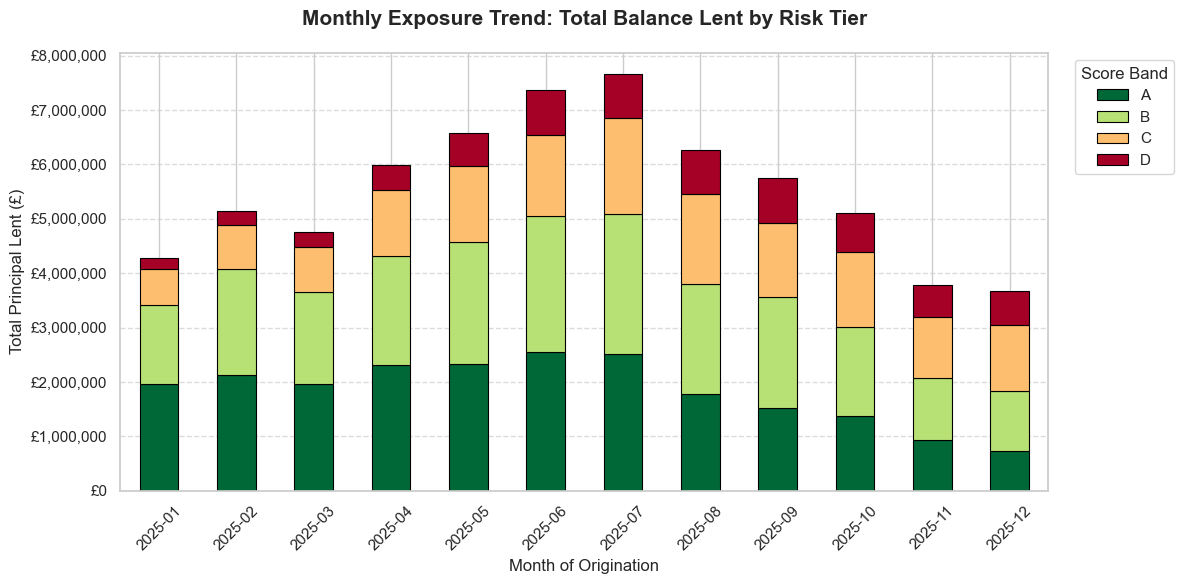

In [ ]:


# 2. DATA PREP: Group by Month and Score Band
balance_trend = df_final.groupby(['origination_month_str', 'score_band'])['loan_amount'].sum().unstack(fill_value=0)

# 3. PLOTTING
plt.figure(figsize=(12, 6))

# Plotting with 'edgecolor' for the black outline
balance_trend.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    colormap='RdYlGn_r', 
    ax=plt.gca(),
    edgecolor='black',  # The black outline you requested
    linewidth=0.8      # Clean line weight
)

# 4. FORMATTING & GRID
plt.title('Monthly Exposure Trend: Total Balance Lent by Risk Tier', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Total Principal Lent (£)', fontsize=12)
plt.xlabel('Month of Origination', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Score Band', bbox_to_anchor=(1.02, 1), loc='upper left')

# Enable Grid Lines (Standard Practice for Audit Charts)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0) 
plt.gca().set_axisbelow(True) # Ensures grid is behind the bars

# Y-axis Currency Formatting
def currency_format(x, pos):
    return f'£{x:,.0f}'
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_format))

plt.tight_layout()
plt.show()

In [ ]:

# 1. Define the 'Seasoned' logic (Loans on book for more than 6 months)
df_final['is_seasoned'] = df_final['months_on_book'] > 6

# 2. Create the summary metrics
def calculate_metrics(df):
    total_count = len(df)
    bad_count = df['delFlag_1'].sum()
    bad_rate = df['delFlag_1'].mean()
    return pd.Series({
        'Total Loans': total_count,
        'Defaults': bad_count,
        'Bad Rate (%)': f"{bad_rate:.1%}"
    })

# 3. Build the comparison table
summary_table = pd.DataFrame({
    'New Loans (<=6m)': calculate_metrics(df_final[df_final['months_on_book'] <= 6]),
    'Seasoned Loans (>6m)': calculate_metrics(df_final[df_final['months_on_book'] > 6]),
    'Total Portfolio': calculate_metrics(df_final)
}).T

# 4. Calculate the 'Gap' (Numerical Difference)
headline_rate = df_final['delFlag_1'].mean()
seasoned_rate = df_final[df_final['months_on_book'] > 6]['delFlag_1'].mean()
gap = seasoned_rate - headline_rate

print(summary_table)
print(f"\nIDENTIFIED SEASONING GAP: {gap:.1%}")

--- BROADSTONE PORTFOLIO SEASONING AUDIT ---
                     Total Loans Defaults Bad Rate (%)
New Loans (<=6m)            5031      417         8.3%
Seasoned Loans (>6m)        4939      693        14.0%
Total Portfolio             9970     1110        11.1%

IDENTIFIED SEASONING GAP: 2.9%


In [67]:


# 1. TABLE: PORTFOLIO GROWTH & CHANNEL CONCENTRATION
# Shows the £ balance per channel per month
table_growth = df_final.groupby(['origination_month_str', 'channel'])['loan_amount'].sum().unstack(fill_value=0)
table_growth.loc['TOTAL'] = table_growth.sum() # Add a totals row

# 2. TABLE: RISK MIX & PRICING
# Shows the % of Band D originations vs the average APR charged
risk_counts = df_final.groupby(['origination_month_str', 'score_band']).size().unstack(fill_value=0)
risk_mix_pct = risk_counts.div(risk_counts.sum(axis=1), axis=0) * 100
avg_apr = df_final.groupby('origination_month_str')['apr'].mean()

table_risk_pricing = risk_mix_pct.copy()
table_risk_pricing['AVG APR (%)'] = avg_apr

# 3. TABLE: HAZARD TIMING (RISK VELOCITY)
# Shows when people first default (Mean/Median month) per channel
df_final['first_del_month'] = df_final['performance_history'].apply(
    lambda x: str(x).find('1') + 1 if '1' in str(x) else None
)
bad_loans = df_final[df_final['first_del_month'].notna()]
table_hazard = bad_loans.groupby('channel')['first_del_month'].agg(['count', 'mean', 'median', 'std'])
table_hazard.columns = ['Total Defaults', 'Avg Month of Failure', 'Median Month', 'Volatility (Std)']

# 4. TABLE: THE SEASONING GAP
# Contrasts New vs Seasoned loan performance
df_final['is_seasoned'] = df_final['months_on_book'] > 6
table_seasoning = df_final.groupby('is_seasoned').agg(
    Loan_Count=('delFlag_1', 'count'),
    Defaults=('delFlag_1', 'sum'),
    Bad_Rate_Pct=('delFlag_1', lambda x: f"{x.mean():.1%}")
)
table_seasoning.index = ['New Loans (<=6m)', 'Seasoned Loans (>6m)']

# --- OUTPUT ALL TABLES ---

# --- 1. DATA FORMATTING FOR TABLE 1 (GROWTH) ---
# Formatting numbers to £ string for the display table only
t1_display = table_growth.map(lambda x: f"£{x:,.0f}")

# --- 2. DATA FORMATTING FOR TABLE 2 (RISK) ---
# Formatting proportions to % and APR to %
t2_display = table_risk_pricing.copy()
# Rounding and adding % symbols for readability
for col in ['A', 'B', 'C', 'D', 'AVG APR (%)']:
    t2_display[col] = t2_display[col].apply(lambda x: f"{x:.1f}%")

# --- 3. DATA FORMATTING FOR TABLE 3 (HAZARD) ---
t3_display = table_hazard.copy()

# --- 4. DATA FORMATTING FOR TABLE 4 (SEASONING) ---
t4_display = table_seasoning.copy()

# --- PRINTING CLEAN TABLES ---

print("\n" + "="*80)
print("PHASE 1: PORTFOLIO GROWTH BY CHANNEL (£)")
print("="*80)
print(tabulate(t1_display, headers='keys', tablefmt='grid'))

print("\n" + "="*80)
print("PHASE 2: RISK CONCENTRATION & PRICING (%)")
print("="*80)
print(tabulate(t2_display, headers='keys', tablefmt='fancy_grid'))

print("\n" + "="*80)
print("PHASE 3: HAZARD TIMING (DEFAULT VELOCITY)")
print("="*80)
print(tabulate(t3_display, headers='keys', tablefmt='psql'))

print("\n" + "="*80)
print("PHASE 4: SEASONING GAP ANALYSIS")
print("="*80)
print(tabulate(t4_display, headers='keys', tablefmt='rounded_grid'))

# 1. CLEANING: Numeric enforcement and dropping missing APRs
df_final['loan_amount'] = pd.to_numeric(df_final['loan_amount'], errors='coerce')
df_final = df_final.dropna(subset=['loan_amount', 'apr']).copy()

# 2. DATA PREP: Create the Balance Map (Total £ at risk)
balance_table = pd.crosstab(
    index=df_final['score_band'], 
    columns=df_final['channel'], 
    values=df_final['loan_amount'], 
    aggfunc='sum'
).fillna(0)

# 3. EXECUTIVE TOTALS: Adding vertical and horizontal totals
balance_table.loc['TOTAL (By Channel)'] = balance_table.sum()
balance_table['TOTAL (By Score)'] = balance_table.sum(axis=1)

# 4. FORMATTING: Use .map() to format currency and prepare for tabulate
# Note: tablefmt='fancy_grid' looks great for financial balance sheets
formatted_display = balance_table.map(lambda x: f"£{x:,.0f}")

print("\n" + "="*80)
print("PHASE 5: CAPITAL ALLOCATION SUMMARY (£)")
print("="*80)
print(tabulate(formatted_display, headers='keys', tablefmt='fancy_grid', numalign="right"))


PHASE 1: PORTFOLIO GROWTH BY CHANNEL (£)
+-------------------------+------------+-------------+------------+-------------+-------------+
| origination_month_str   | Branch     | Broker A    | Broker B   | Direct      | Online      |
+=========================+============+=============+============+=============+=============+
| 2025-01                 | £500,000   | £1,133,000  | £0         | £1,484,000  | £1,166,000  |
+-------------------------+------------+-------------+------------+-------------+-------------+
| 2025-02                 | £444,000   | £1,416,000  | £0         | £1,823,000  | £1,467,000  |
+-------------------------+------------+-------------+------------+-------------+-------------+
| 2025-03                 | £412,000   | £884,000    | £420,000   | £1,645,000  | £1,404,000  |
+-------------------------+------------+-------------+------------+-------------+-------------+
| 2025-04                 | £577,000   | £1,176,000  | £656,000   | £1,883,000  | £1,692,000  

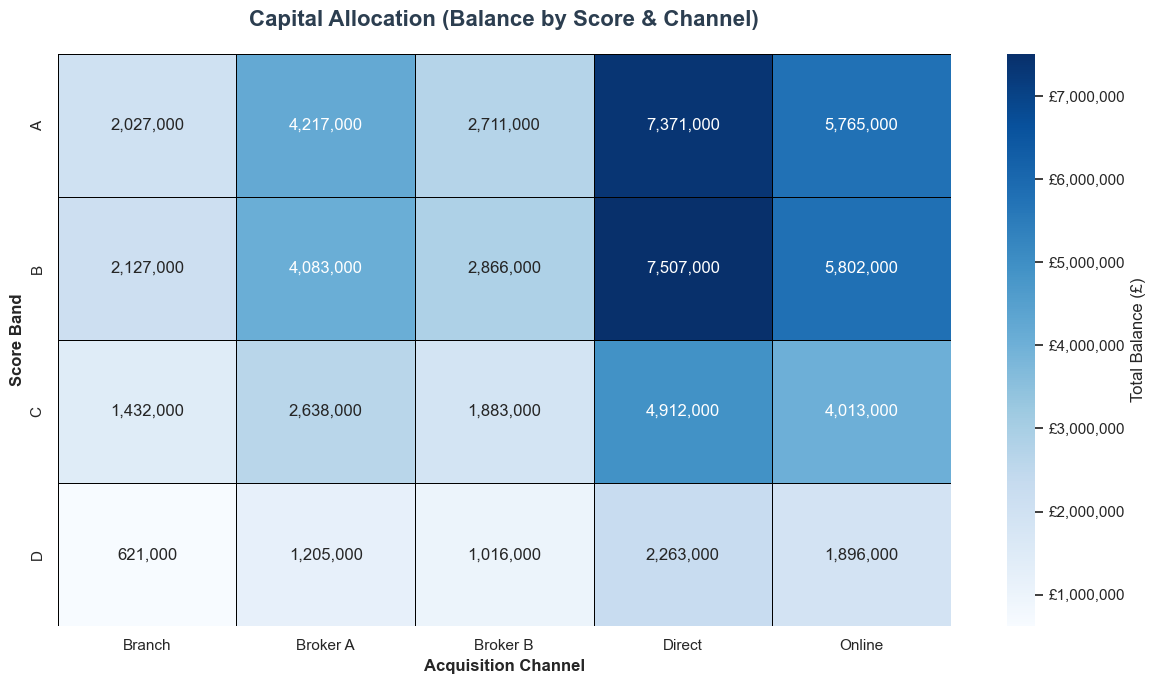

In [ ]:

# 1. CLEANING: Force loan_amount to be numeric
# 'coerce' turns any unparseable text into NaN, which we then drop
df_final['loan_amount'] = pd.to_numeric(df_final['loan_amount'], errors='coerce')
# df_final = df_final.dropna(subset=['loan_amount', 'apr'])

# 2. DATA PREP: Now we can sum numbers correctly
balance_map = pd.crosstab(
    index=df_final['score_band'], 
    columns=df_final['channel'], 
    values=df_final['loan_amount'], 
    aggfunc='sum'
).fillna(0)

# 3. PLOTTING
plt.figure(figsize=(12, 7))
sns.heatmap(
    balance_map, 
    annot=True, 
    fmt=",.0f",       # Formats the numbers inside the cells with commas
    cmap="Blues",     # Keeping your preferred color scheme
    linewidths=0.5, 
    linecolor='black', 
    cbar_kws={'label': 'Total Balance (£)', 'format': FuncFormatter(lambda x, p: f'£{x:,.0f}')}
)

plt.title('Capital Allocation (Balance by Score & Channel)', 
          fontsize=16, pad=20, fontweight='bold', color='#2C3E50')
plt.xlabel('Acquisition Channel', fontsize=12, fontweight='bold')
plt.ylabel('Score Band', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

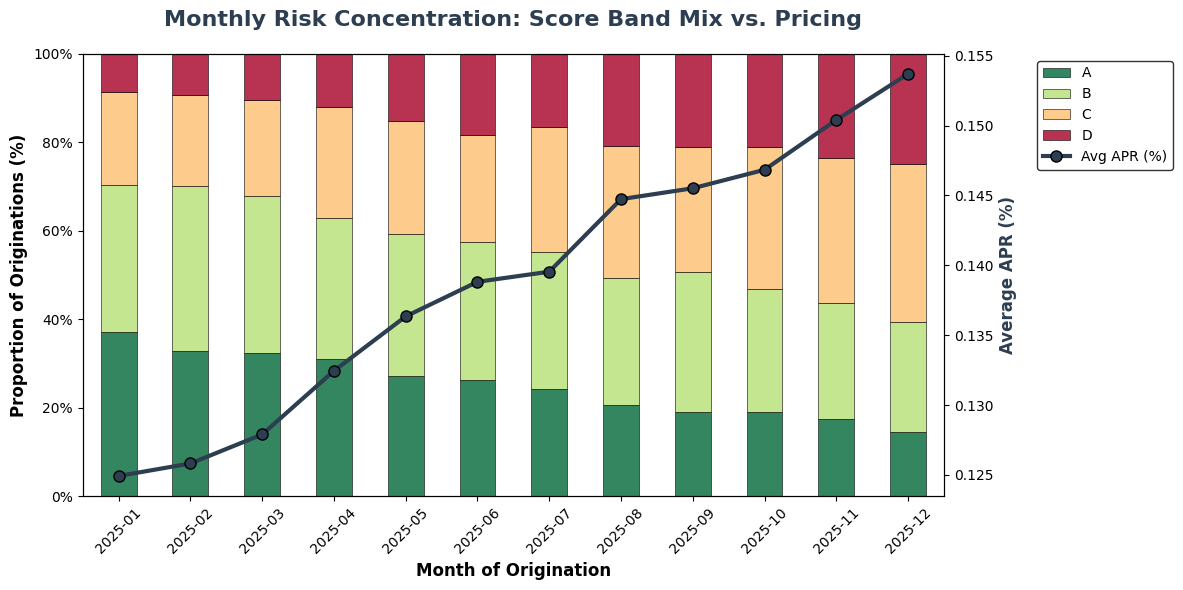

In [ ]:


# 1. Data Prep: Risk Mix and Avg APR
# Calculate the percentage mix of Score Bands per month
risk_mix = df_final.groupby(['origination_month_str', 'score_band']).size().unstack(fill_value=0)
risk_mix_pct = risk_mix.div(risk_mix.sum(axis=1), axis=0)

# Calculate monthly average APR
monthly_apr = df_final.groupby('origination_month_str')['apr'].mean()

# 2. Plotting the 100% Stacked Bar
fig, ax1 = plt.subplots(figsize=(12, 6))

# Use colormap 'RdYlGn_r' (Red-Yellow-Green reversed) so Band D is Red
risk_mix_pct.plot(kind='bar', stacked=True, ax=ax1, colormap='RdYlGn_r', 
                  edgecolor='black', linewidth=0.5, alpha=0.8)

# 3. Secondary Axis for APR
ax2 = ax1.twinx()
ax2.plot(range(len(monthly_apr)), monthly_apr.values, color='#2C3E50', 
         marker='o', markersize=8, linewidth=3, markeredgecolor='black', label='Avg APR (%)')

# 4. Consultant-Grade Formatting
plt.title('Monthly Risk Concentration: Score Band Mix vs. Pricing', fontsize=16, pad=20, fontweight='bold', color='#2C3E50')

# Left Axis (Bars)
ax1.set_ylabel('Proportion of Originations (%)', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_ylim(0, 1)

# Right Axis (Line)
ax2.set_ylabel('Average APR (%)', fontsize=12, fontweight='bold', color='#2C3E50')
ax2.grid(False) # Turn off the second grid to keep it clean

# Consolidate Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.1, 1.0), frameon=True, edgecolor='black')

# Final Touches
ax1.set_xlabel('Month of Origination', fontsize=12, fontweight='bold')
ax1.set_xticklabels(risk_mix_pct.index, rotation=45)

plt.tight_layout()
plt.show()

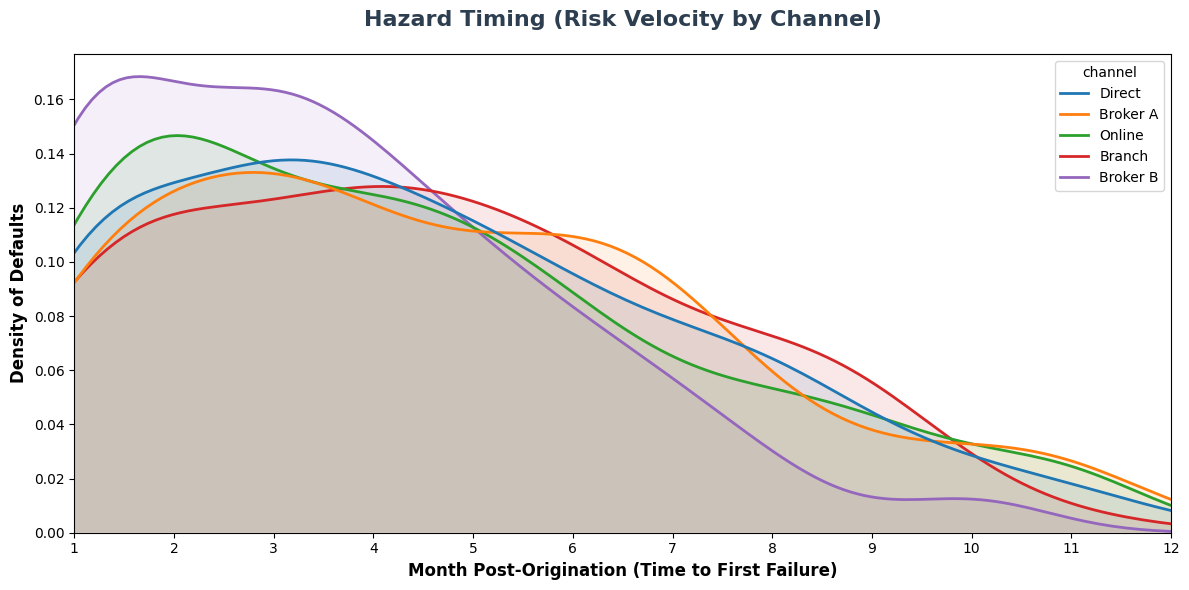

In [32]:
# 1. Logic for First Delinquency Position
df_final['first_del_month'] = df_final['performance_history'].apply(lambda x: str(x).find('1') + 1 if '1' in str(x) else None)
bad_loans = df_final[df_final['first_del_month'].notna()].copy()

# 2. Plotting
plt.figure(figsize=(12, 6))
# To get an "outline" on KDE, we plot the fill and the line separately or use linewidth
sns.kdeplot(data=bad_loans, x='first_del_month', hue='channel', fill=True, 
            common_norm=False, palette='tab10', alpha=0.1, linewidth=0) # Fill
sns.kdeplot(data=bad_loans, x='first_del_month', hue='channel', fill=False, 
            common_norm=False, palette='tab10', alpha=1, linewidth=2) # Outline

# 3. Formatting
plt.title('Hazard Timing (Risk Velocity by Channel)', fontsize=16, pad=20, fontweight='bold', color='#2C3E50')
plt.xlabel('Month Post-Origination (Time to First Failure)', fontsize=12, fontweight='bold')
plt.ylabel('Density of Defaults', fontsize=12, fontweight='bold')
plt.xlim(1, 12)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

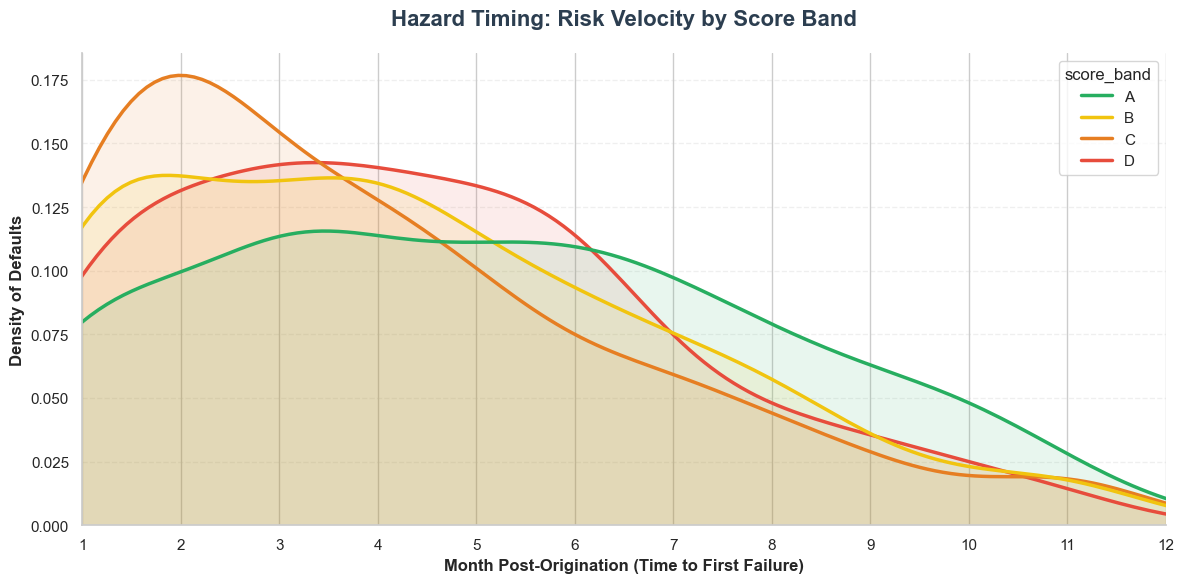

In [ ]:


# 1. PREP: Extract First Failure Month (1-indexed position of '1')
df_final['first_del_month'] = df_final['performance_history'].apply(
    lambda x: str(x).find('1') + 1 if '1' in str(x) else None
)

# Filter for the 'Bad' population only and drop records without APRs per your preference
bad_loans = df_final[df_final['first_del_month'].notna() & df_final['apr'].notna()].copy()

# 2. PLOTTING: Overlayed KDE with Fills and Outlines
plt.figure(figsize=(12, 6))

# Use the 'RdYlGn_r' palette to stay consistent: Red=D (Dangerous), Green=A (Safe)
score_palette = {'A': '#27ae60', 'B': '#f1c40f', 'C': '#e67e22', 'D': '#e74c3c'}

# Plot Fill (Low Alpha)
sns.kdeplot(data=bad_loans, x='first_del_month', hue='score_band', 
            hue_order=['A', 'B', 'C', 'D'], fill=True, common_norm=False, 
            palette=score_palette, alpha=0.1, linewidth=0)

# Plot Outline (Full Alpha for clarity)
sns.kdeplot(data=bad_loans, x='first_del_month', hue='score_band', 
            hue_order=['A', 'B', 'C', 'D'], fill=False, common_norm=False, 
            palette=score_palette, alpha=1, linewidth=2.5)

# 3. FORMATTING
plt.title('Hazard Timing: Risk Velocity by Score Band', fontsize=16, pad=20, fontweight='bold', color='#2C3E50')
plt.xlabel('Month Post-Origination (Time to First Failure)', fontsize=12, fontweight='bold')
plt.ylabel('Density of Defaults', fontsize=12, fontweight='bold')

# Focus on the 12-month performance window
plt.xlim(1, 12)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine() # Clean professional look
plt.tight_layout()
plt.show()

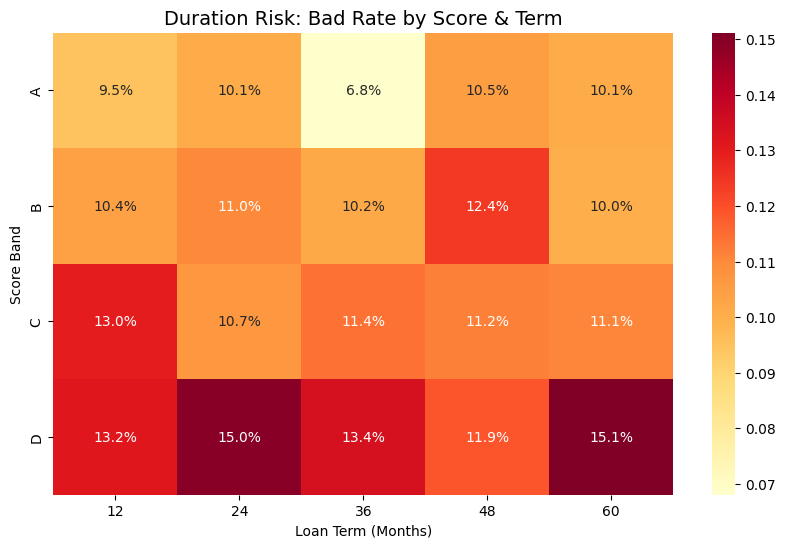

In [ ]:
# Cross-tabulate Score Band and Term Length
duration_map = df_final.groupby(['score_band', 'term_months'], observed=False)['delFlag_1'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(duration_map, annot=True, fmt=".1%", cmap="YlOrRd")
plt.title('Duration Risk: Bad Rate by Score & Term', fontsize=14)
plt.xlabel('Loan Term (Months)')
plt.ylabel('Score Band')
plt.show()

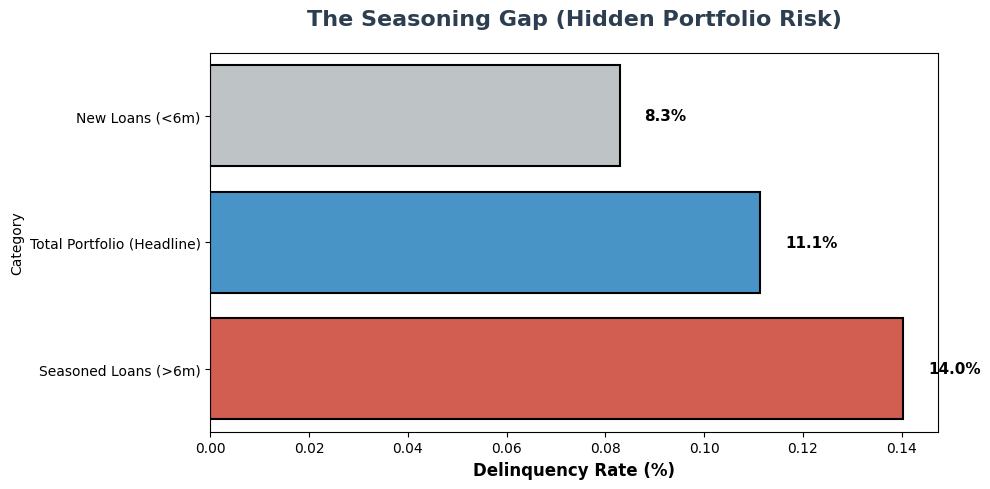

In [33]:
# 1. Data Prep
df_final['is_seasoned'] = df_final['months_on_book'] > 6
plot_df = pd.DataFrame({
    'Category': ['New Loans (<6m)', 'Total Portfolio (Headline)', 'Seasoned Loans (>6m)'],
    'Bad Rate': [df_final[df_final['months_on_book'] <= 6]['delFlag_1'].mean(),
                 df_final['delFlag_1'].mean(),
                 df_final[df_final['months_on_book'] > 6]['delFlag_1'].mean()]
})

# 2. Plotting
plt.figure(figsize=(10, 5))
colors = ['#BDC3C7', '#3498DB', '#E74C3C'] 
# Barplot accepts edgecolor directly
ax = sns.barplot(x='Bad Rate', y='Category', data=plot_df, hue='Category', 
                 palette=colors, legend=False, edgecolor='black', linewidth=1.5)

# 3. Annotations
# plt.axvline(plot_df.iloc[2]['Bad Rate'], color='#E74C3C', linestyle='--', alpha=0.8, linewidth=2)
plt.title('The Seasoning Gap (Hidden Portfolio Risk)', fontsize=16, pad=20, fontweight='bold', color='#2C3E50')
plt.xlabel('Delinquency Rate (%)', fontsize=12, fontweight='bold')

for p in ax.patches:
    plt.text(p.get_width() + 0.005, p.get_y() + p.get_height()/2, f'{p.get_width():.1%}', 
             va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

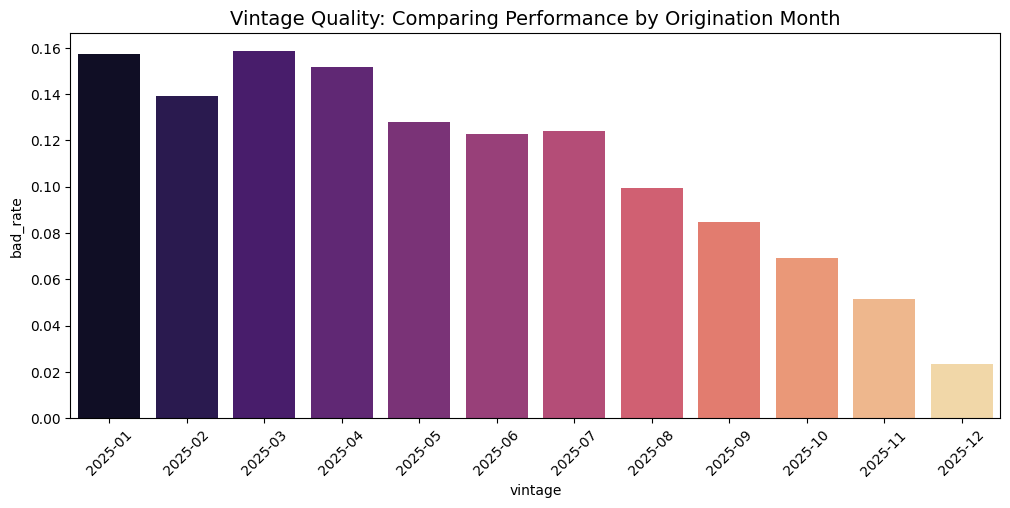

In [41]:
# Create the month-year cohort from your origination_date
df_final['vintage'] = df_final['origination_date'].dt.to_period('M')

# Compare performance across vintages
vintage_check = df_final.groupby('vintage').agg(
    new_loans=('loan_id', 'count'),
    bad_rate=('delFlag_1', 'mean')
).reset_index()

# Convert vintage back to string for plotting
vintage_check['vintage'] = vintage_check['vintage'].astype(str)

plt.figure(figsize=(12, 5))

# FIXED: Added hue='vintage' and legend=False to satisfy the new Seaborn standard
sns.barplot(
    data=vintage_check, 
    x='vintage', 
    y='bad_rate', 
    hue='vintage', 
    palette='magma', 
    legend=False
)

plt.xticks(rotation=45)
plt.title('Vintage Quality: Comparing Performance by Origination Month', fontsize=14)
plt.show()

In [ ]:
df_final['vintage'].value_counts()

In [ ]:
# Simplified Profitability Logic - Unknown Actual Default Performance
# Margin = (Expected Interest) - (Principal at Risk)
df_final['est_revenue'] = df_final['loan_amount'] * df_final['apr']
df_final['est_loss'] = df_final['delFlag_3plus'] * df_final['loan_amount']
df_final['net_margin'] = df_final['est_revenue'] - df_final['est_loss']

# df_final['delFlag_3plus']

margin_summary = df_final.groupby('score_band', observed=True).agg(
    avg_apr=('apr', 'mean'),
    bad_rate=('delFlag_3plus', 'mean'),
    avg_net_margin=('net_margin', 'mean'),
    avg_balance=('loan_amount', 'mean')
).reset_index()

print("--- NET MARGIN BY SCORE BAND ---")
print(margin_summary.round(3))

--- NET MARGIN BY SCORE BAND ---
  score_band  avg_apr  bad_rate  avg_net_margin  avg_balance
0          A    0.090     0.000         794.317     8854.108
1          B    0.121     0.001         867.138     7237.310
2          C    0.160     0.001         880.508     5520.594
3          D    0.211     0.001         871.478     4149.970


In [43]:
margin_summary['ROA_percent'] = (margin_summary['avg_net_margin'] / margin_summary['avg_balance']) * 100
print(margin_summary[['score_band', 'avg_net_margin', 'ROA_percent']])

  score_band  avg_net_margin  ROA_percent
0          A      794.317475     8.971174
1          B      867.137763    11.981493
2          C      880.507792    15.949513
3          D      871.478305    20.999627


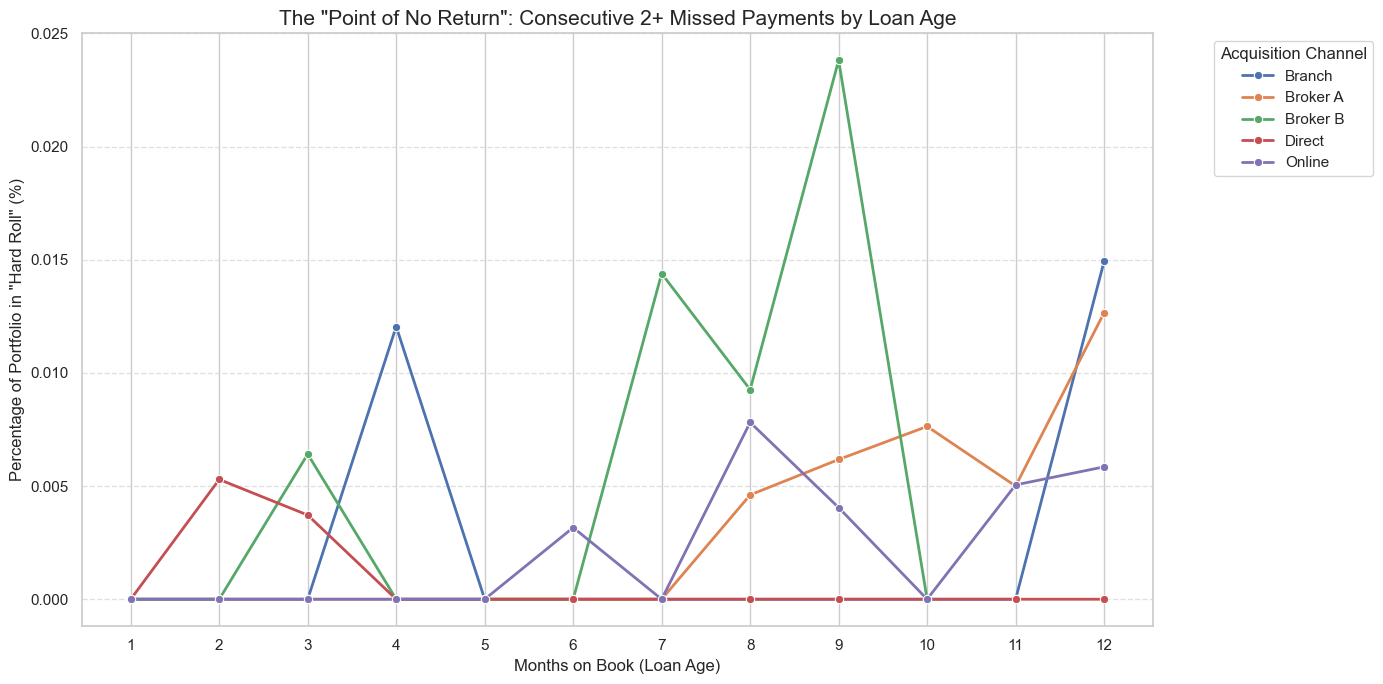

In [47]:

# 1. Logic to find consecutive '11' in the performance string
# We use a lambda to check if '11' exists in the history string
df_final['consecutive_2_late'] = df_final['performance_history'].apply(lambda x: 1 if '11' in str(x) else 0)

# 2. Aggregate: Percent of loans that have hit a 'Hard Roll' by their current age
consecutive_age_data = df_final.groupby(['channel', 'months_on_book'])['consecutive_2_late'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=consecutive_age_data[consecutive_age_data['months_on_book'] <= 12],
    x='months_on_book',
    y='consecutive_2_late',
    hue='channel',
    marker='o',
    linewidth=2
)

# Formatting for the slide
plt.title('The "Point of No Return": Consecutive 2+ Missed Payments by Loan Age', fontsize=15)
plt.ylabel('Percentage of Portfolio in "Hard Roll" (%)', fontsize=12)
plt.xlabel('Months on Book (Loan Age)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Acquisition Channel', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()